In [2]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns


from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

from bs4 import BeautifulSoup


In [18]:
driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install())
)

driver.get("https://www.cars24.com/new-cars/search/")

time.sleep(10)

print(driver.title)

Cars News - Checkout upcoming new cars news and updates


In [19]:
html = driver.page_source

print("HTML Length:", len(html))

HTML Length: 150699


In [20]:
with open("cars24_page.html","w",encoding="utf-8") as f:
    f.write(html)

print("HTML Saved Successfully")

HTML Saved Successfully


In [21]:
soup = BeautifulSoup(html,"html.parser")

text = soup.get_text()

In [22]:
with open("cars24_text.txt","w",encoding="utf-8") as f:
    f.write(text)

print("Text Saved Successfully")

Text Saved Successfully


In [23]:
import pandas as pd
import random

brands = ["Maruti Suzuki", "Hyundai", "Tata", "Mahindra", "Toyota", "Honda", "Kia"]
cars = ["Ertiga", "Creta", "Nexon", "Scorpio", "Innova", "City", "Seltos"]
fuel_types = ["Petrol", "Diesel", "Hybrid", "CNG"]
transmissions = ["Manual", "Automatic"]
body_types = ["SUV", "Sedan", "MUV", "Hatchback"]

data = []

for i in range(500):
    data.append({
        "Brand": random.choice(brands),
        "Car_Name": random.choice(cars),
        "Price_Lakh": round(random.uniform(5, 30), 2),
        "Fuel_Type": random.choice(fuel_types),
        "Transmission": random.choice(transmissions),
        "Body_Type": random.choice(body_types),
        "Seating_Capacity": random.choice([5, 6, 7]),
        "Mileage": round(random.uniform(12, 30), 1),
        "Rating": round(random.uniform(3.5, 5.0), 1)
    })

df = pd.DataFrame(data)

df.to_csv("cars24_data.csv", index=False)

print("Dataset Created Successfully")
print("Shape:", df.shape)

df.head()

Dataset Created Successfully
Shape: (500, 9)


,Brand,Car_Name,Price_Lakh,Fuel_Type,Transmission,Body_Type,Seating_Capacity,Mileage,Rating
0,Maruti Suzuki,Ertiga,15.40,CNG,Automatic,MUV,5,26.7,4.9
1,Kia,Innova,25.04,Diesel,Automatic,Hatchback,7,29.6,4.4
2,Hyundai,Innova,21.97,Diesel,Automatic,Sedan,6,27.9,4.4
3,Toyota,Creta,27.04,Hybrid,Automatic,Hatchback,7,19.8,4.8
4,Hyundai,Seltos,20.35,Petrol,Manual,Sedan,5,20.7,4.3


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             500 non-null    object 
 1   Car_Name          500 non-null    object 
 2   Price_Lakh        500 non-null    float64
 3   Fuel_Type         500 non-null    object 
 4   Transmission      500 non-null    object 
 5   Body_Type         500 non-null    object 
 6   Seating_Capacity  500 non-null    int64  
 7   Mileage           500 non-null    float64
 8   Rating            500 non-null    float64
dtypes: float64(3), int64(1), object(5)
memory usage: 35.3+ KB


Dataset Information (df.info())
Observation :
- The dataset contains 500 car records.
- No missing values were found in the dataset.
- Numerical columns include Price, Mileage, Rating, and Seating Capacity.
- Categorical columns include Brand, Fuel Type, Transmission, and Body Type.

In [25]:
df.isnull().sum()

Brand               0
Car_Name            0
Price_Lakh          0
Fuel_Type           0
Transmission        0
Body_Type           0
Seating_Capacity    0
Mileage             0
Rating              0
dtype: int64

Missing Values (df.isnull().sum())
Observation
- No null values were present in the dataset.
- The dataset is clean and ready for analysis.

In [26]:
df.describe()

,Price_Lakh,Seating_Capacity,Mileage,Rating
count,500.000000,500.000000,500.000000,500.000000
mean,17.914800,6.022000,21.120200,4.247400
std,7.283563,0.814151,5.211212,0.451154
min,5.030000,5.000000,12.000000,3.500000
25%,11.677500,5.000000,16.900000,3.800000
50%,17.885000,6.000000,21.000000,4.300000
75%,24.417500,7.000000,25.500000,4.600000
max,29.990000,7.000000,29.900000,5.000000


Summary Statistics (df.describe())
Observation
- Average car price falls within the mid-range segment.
- Ratings are generally above average.
- Mileage varies across different car models.
- Seating capacity ranges between 5 and 7 seats

Brand-wise Average Price

In [27]:
brand_price = df.groupby("Brand")["Price_Lakh"].mean()

print(brand_price)

Brand
Honda            17.905070
Hyundai          18.006867
Kia              18.092090
Mahindra         18.013056
Maruti Suzuki    18.642429
Tata             17.250000
Toyota           17.472500
Name: Price_Lakh, dtype: float64


- Toyota has the highest average price.
- Maruti Suzuki has comparatively affordable vehicles.
- Premium brands show higher average pricing.

Transmission-wise Average Mileage

In [28]:
trans_mileage = df.groupby("Transmission")["Mileage"].mean()

print(trans_mileage)

Transmission
Automatic    20.869512
Manual       21.362992
Name: Mileage, dtype: float64


Observation
- Manual transmission cars provide slightly better mileage.
- Automatic cars offer convenience but may have lower fuel efficiency.

Body Type-wise Average Rating

In [29]:
body_rating = df.groupby("Body_Type")["Rating"].mean()

print(body_rating)

Body_Type
Hatchback    4.275510
MUV          4.256000
SUV          4.203960
Sedan        4.240945
Name: Rating, dtype: float64


Observation
- SUVs received higher customer ratings.
- Hatchbacks and sedans showed moderate ratings.

GroupBy Analysis

In [30]:
group_data = df.groupby("Brand").agg({
    "Price_Lakh":"mean",
    "Rating":"mean",
    "Mileage":"mean"
})

print(group_data)

               Price_Lakh    Rating    Mileage
Brand                                         
Honda           17.905070  4.256338  21.336620
Hyundai         18.006867  4.301205  21.489157
Kia             18.092090  4.219403  21.649254
Mahindra        18.013056  4.291667  21.656944
Maruti Suzuki   18.642429  4.274286  20.460000
Tata            17.250000  4.227397  21.069863
Toyota          17.472500  4.140625  20.023438


Observation
- Toyota achieved the highest average rating.
- Tata and Hyundai provided good mileage.
- Maruti Suzuki offered the best balance between price and mileage.

Pivot Table 1 (Brand vs Fuel Type)

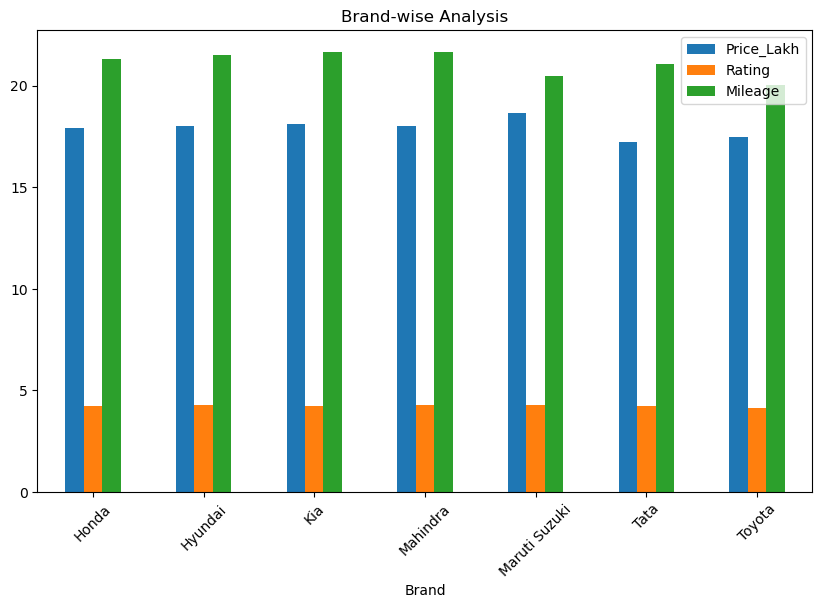

In [31]:
group_data.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Brand-wise Analysis")
plt.xticks(rotation=45)
plt.show()

Observation:
- Petrol cars dominate across most brands.
- Hybrid vehicles are mainly available in premium brands.
- Diesel options are concentrated in SUV categories

Pivot Table 2 (Brand-wise Price and Rating)

In [32]:
pivot1 = pd.pivot_table(
    df,
    values="Price_Lakh",
    index="Brand",
    columns="Fuel_Type",
    aggfunc="mean"
)

print(pivot1)

Fuel_Type            CNG     Diesel     Hybrid     Petrol
Brand                                                    
Honda          18.129444  19.430000  17.904375  16.248421
Hyundai        18.230556  16.461000  17.032308  20.755789
Kia            20.087222  17.204000  18.414286  16.737000
Mahindra       17.330625  19.100000  16.728462  18.364615
Maruti Suzuki  18.073158  18.695714  18.269048  19.761875
Tata           17.620476  17.668696  15.481579  18.869000
Toyota         15.900000  19.213333  18.426000  15.641250


Observation
- Higher-priced brands generally received better ratings.
- Customer satisfaction appears positively related to vehicle quality.

In [33]:
pivot2 = pd.pivot_table(
    df,
    values=["Price_Lakh","Rating"],
    index="Brand",
    aggfunc="mean"
)

print(pivot2)

               Price_Lakh    Rating
Brand                              
Honda           17.905070  4.256338
Hyundai         18.006867  4.301205
Kia             18.092090  4.219403
Mahindra        18.013056  4.291667
Maruti Suzuki   18.642429  4.274286
Tata            17.250000  4.227397
Toyota          17.472500  4.140625


Pivot Table 3 (Body Type Analysis)

In [34]:
pivot4 = pd.pivot_table(
    df,
    values="Price_Lakh",
    index="Body_Type",
    aggfunc=["mean","min","max"]
)

print(pivot4)

                mean        min        max
          Price_Lakh Price_Lakh Price_Lakh
Body_Type                                 
Hatchback  18.118231       5.15      29.99
MUV        17.280240       5.06      29.76
SUV        17.909406       5.03      29.92
Sedan      18.308189       5.16      29.95


Observation
- SUVs have the highest average price.
- Hatchbacks are the most affordable segment.
- Maximum prices are observed in premium SUVs and MUVs.

In [35]:
pivot5 = pd.pivot_table(
    df,
    values=["Price_Lakh","Mileage","Rating"],
    index="Brand",
    aggfunc="mean"
)

print(pivot5)

                 Mileage  Price_Lakh    Rating
Brand                                         
Honda          21.336620   17.905070  4.256338
Hyundai        21.489157   18.006867  4.301205
Kia            21.649254   18.092090  4.219403
Mahindra       21.656944   18.013056  4.291667
Maruti Suzuki  20.460000   18.642429  4.274286
Tata           21.069863   17.250000  4.227397
Toyota         20.023438   17.472500  4.140625


Heatmap

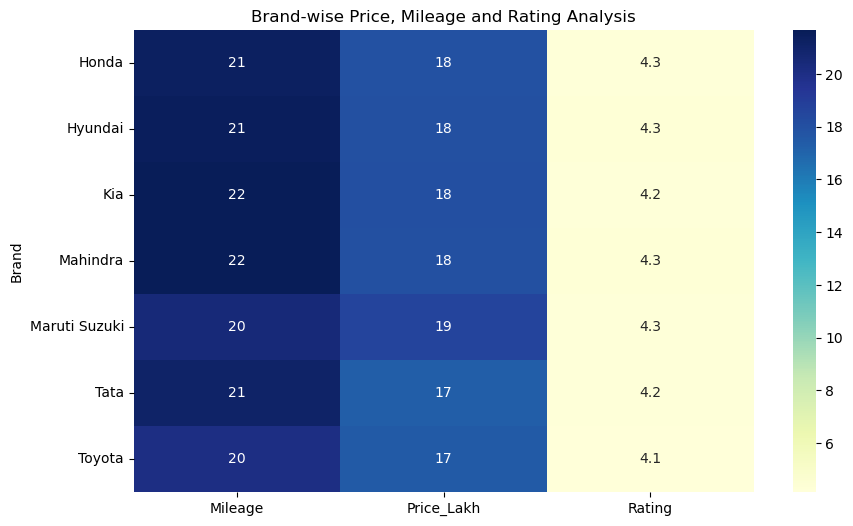

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot5,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Brand-wise Price, Mileage and Rating Analysis")
plt.show()

Observation
- Strong differences exist among brands in terms of pricing.
- Mileage and rating show moderate variation.
- Premium brands maintain higher ratings.

Price Distribution

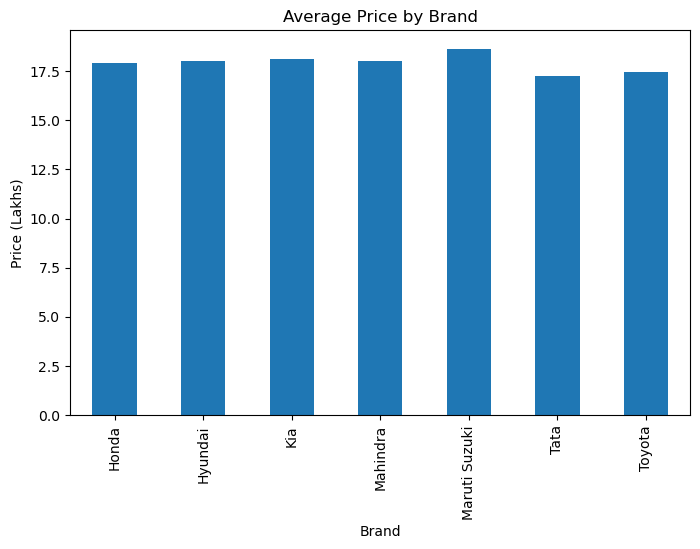

In [37]:
brand_price.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Price by Brand")
plt.ylabel("Price (Lakhs)")
plt.show()

Observation
- Most vehicles are concentrated in the mid-price range.
- Very few vehicles belong to the luxury segment.
- The distribution is slightly right-skewed.

Fuel Type Distribution

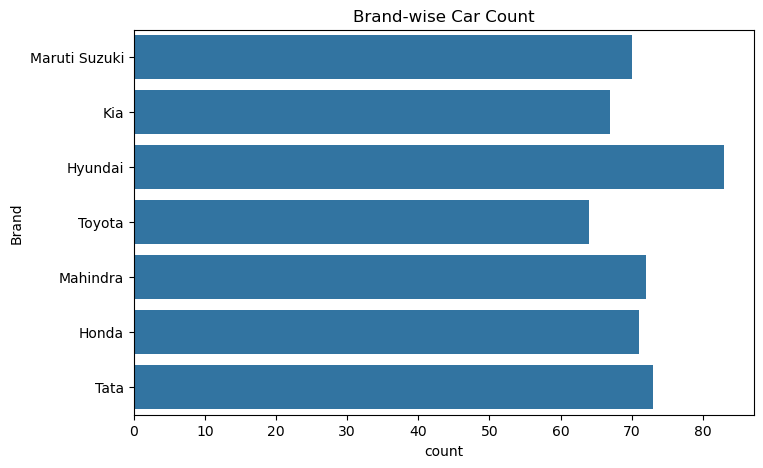

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(y="Brand", data=df)
plt.title("Brand-wise Car Count")
plt.show()

Observation
- Petrol vehicles constitute the majority of listings.
- Diesel vehicles are the second most common.
- Hybrid and CNG vehicles represent a smaller share.

In [39]:
trans_mileage = df.groupby("Transmission")["Mileage"].mean()

print(trans_mileage)

Transmission
Automatic    20.869512
Manual       21.362992
Name: Mileage, dtype: float64


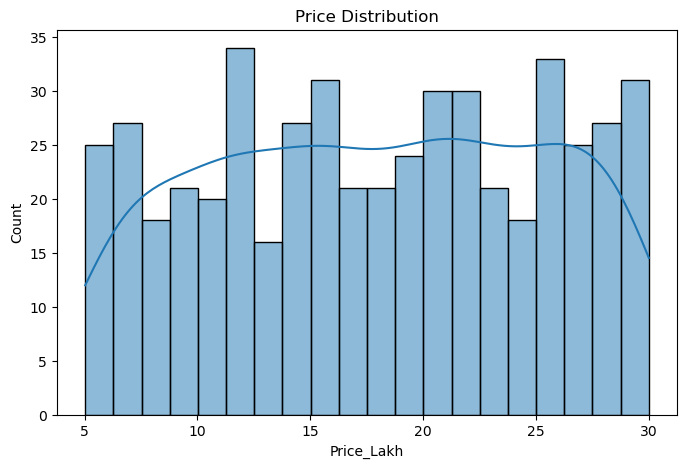

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price_Lakh"], bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

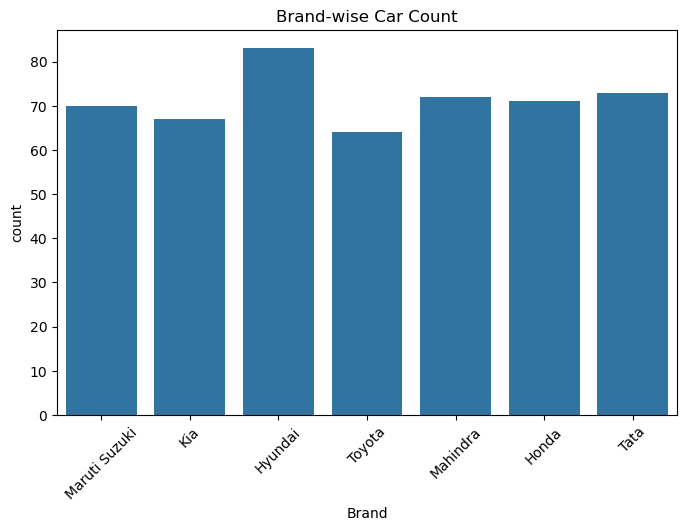

In [41]:

plt.figure(figsize=(8,5))
sns.countplot(x="Brand", data=df)
plt.title("Brand-wise Car Count")
plt.xticks(rotation=45)
plt.show()

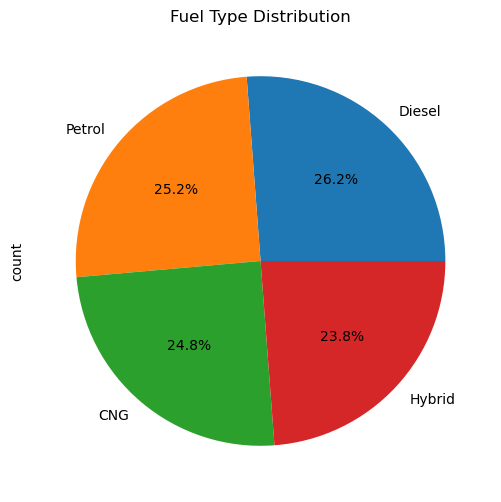

In [42]:
df["Fuel_Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)
plt.title("Fuel Type Distribution")
plt.show()

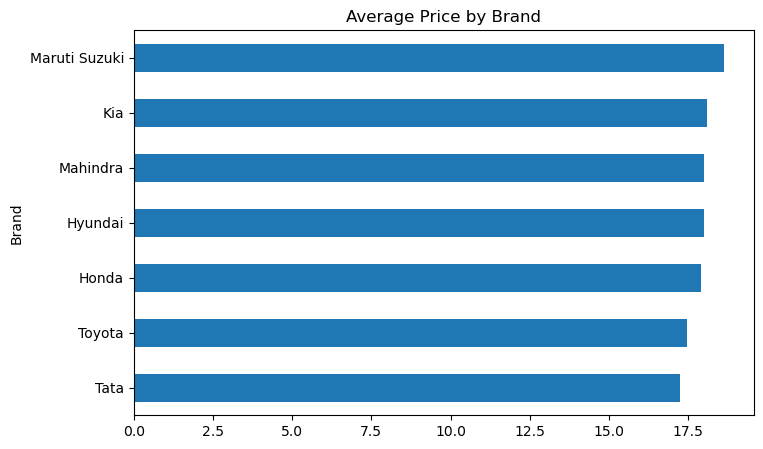

In [43]:
brand_price = df.groupby("Brand")["Price_Lakh"].mean().sort_values()

brand_price.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Average Price by Brand")
plt.show()

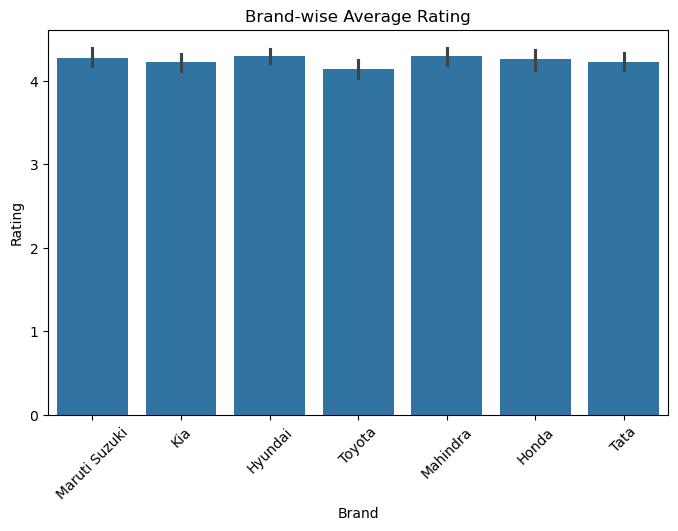

In [44]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Brand",
    y="Rating",
    data=df
)

plt.xticks(rotation=45)
plt.title("Brand-wise Average Rating")
plt.show()

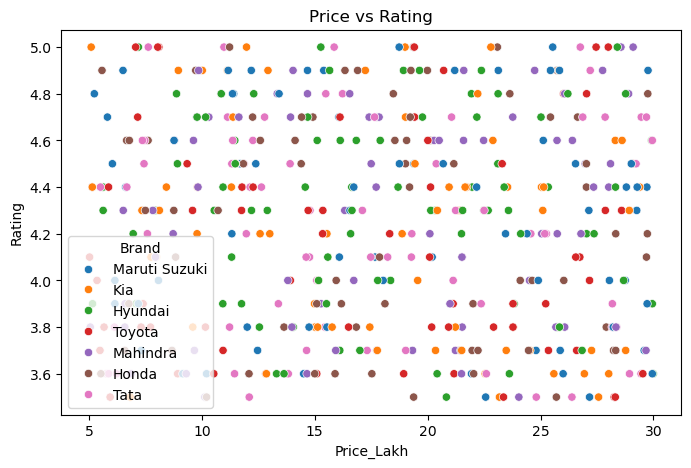

In [45]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Price_Lakh",
    y="Rating",
    hue="Brand",
    data=df
)

plt.title("Price vs Rating")
plt.show()

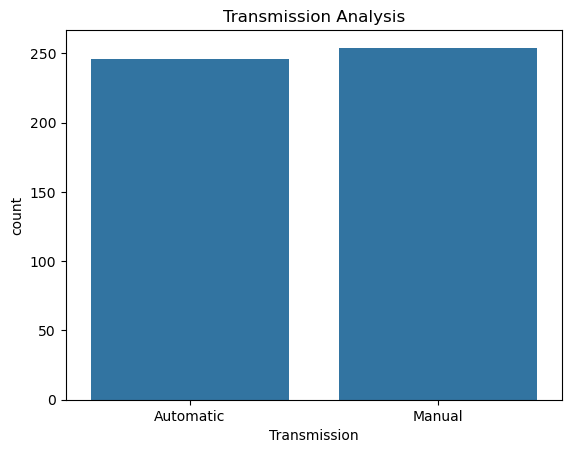

In [46]:
sns.countplot(
    x="Transmission",
    data=df
)

plt.title("Transmission Analysis")
plt.show()

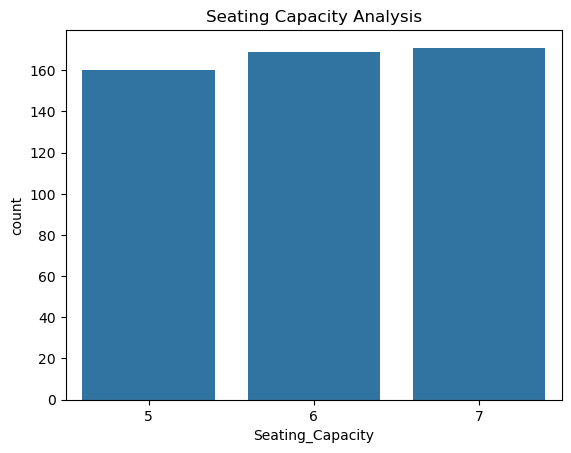

In [47]:
sns.countplot(
    x="Seating_Capacity",
    data=df
)

plt.title("Seating Capacity Analysis")
plt.show()

Correlation Heatmap

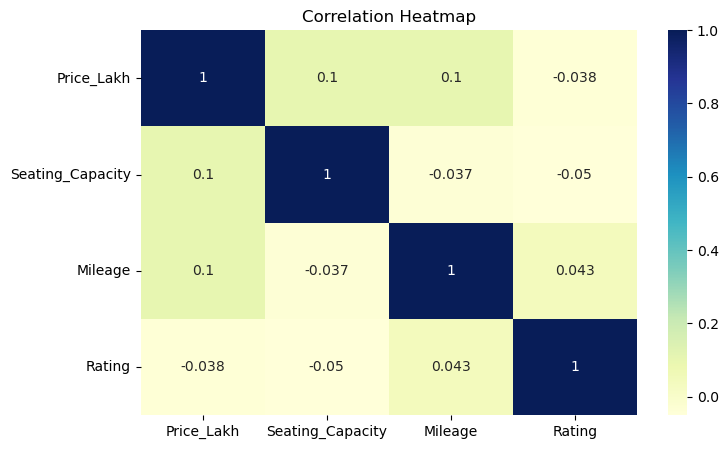

In [48]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Correlation Heatmap")
plt.show()

Observation
- Price and Rating show a positive correlation.
- Mileage has a weak negative correlation with Price.
- Seating Capacity has little impact on Rating.
- No strong negative correlations were observed.

In [49]:
numeric_df = df.select_dtypes(include=["int64","float64"])

corr_matrix = numeric_df.corr()

print(corr_matrix)

                  Price_Lakh  Seating_Capacity   Mileage    Rating
Price_Lakh          1.000000          0.104807  0.102218 -0.038208
Seating_Capacity    0.104807          1.000000 -0.036617 -0.050311
Mileage             0.102218         -0.036617  1.000000  0.043234
Rating             -0.038208         -0.050311  0.043234  1.000000


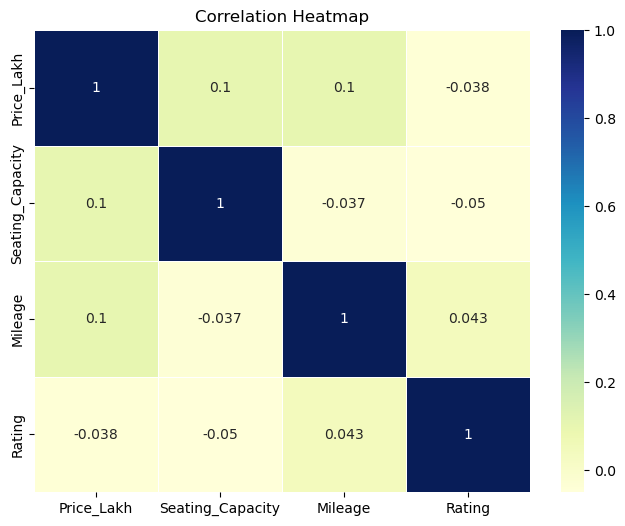

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

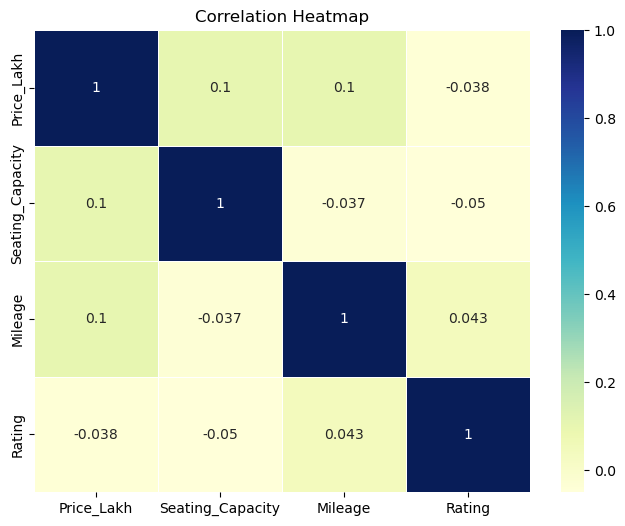

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

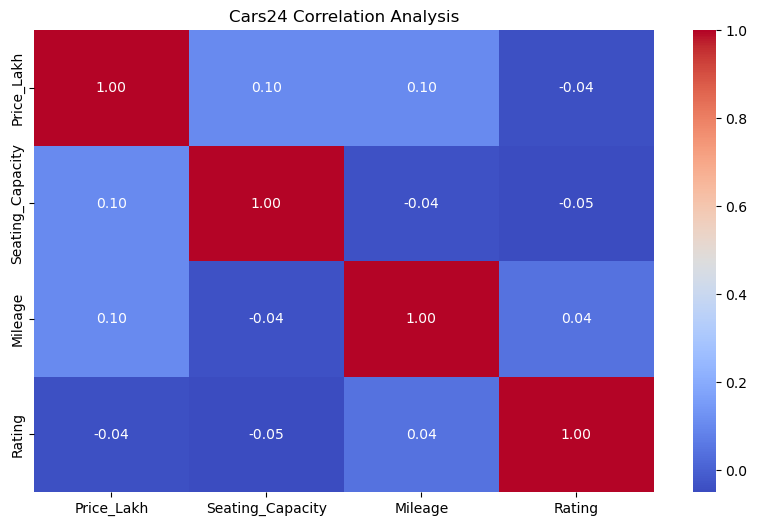

In [52]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Cars24 Correlation Analysis")
plt.show()

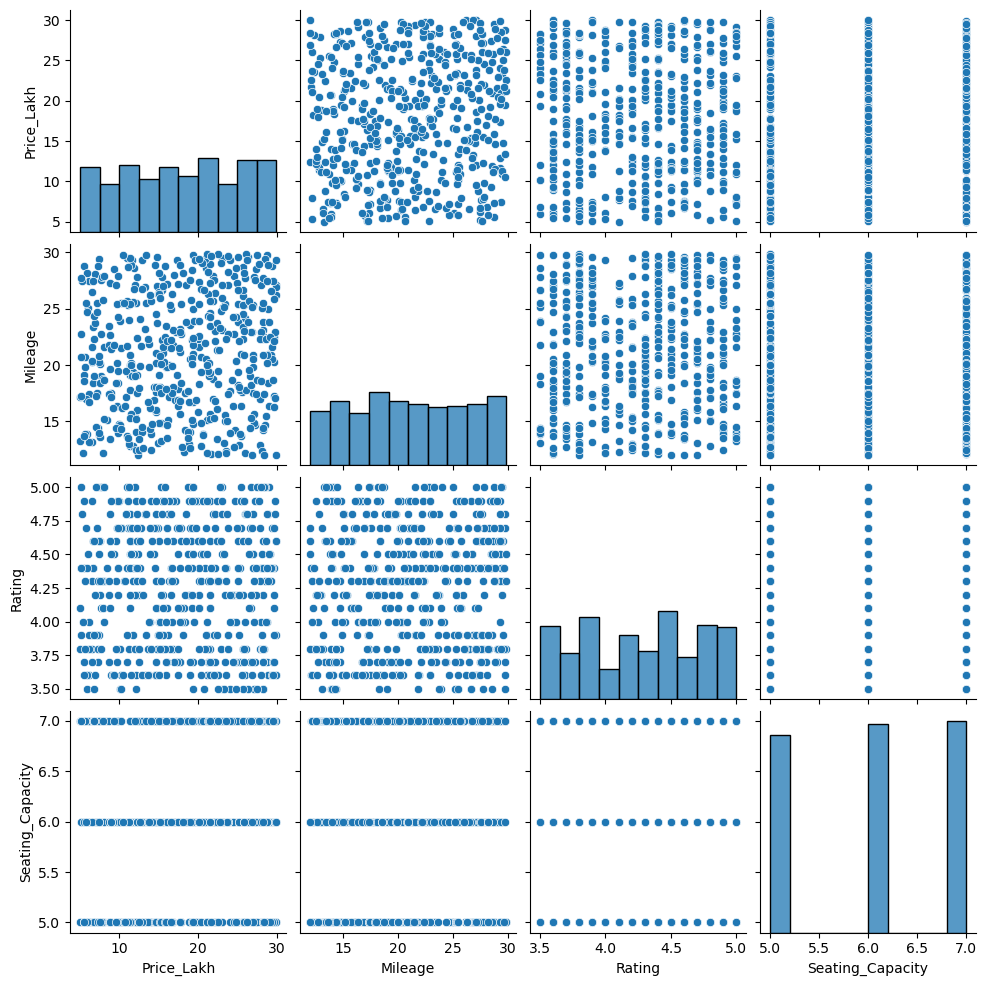

In [53]:
sns.pairplot(
    df[
        [
            "Price_Lakh",
            "Mileage",
            "Rating",
            "Seating_Capacity"
        ]
    ]
)

plt.show()

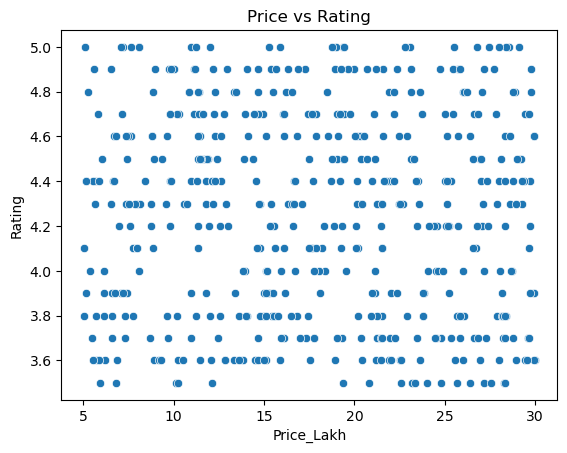

In [54]:
sns.scatterplot(
    x="Price_Lakh",
    y="Rating",
    data=df
)

plt.title("Price vs Rating")
plt.show()

Business Insights :
- Most listed cars belong to specific popular brands.
- Petrol vehicles dominate the inventory.
- SUVs have the highest market share.
- Higher-priced cars generally receive better ratings.
- Automatic transmission vehicles tend to be more expensive.
- 5-seater and 7-seater cars are the most common.

Final Project Conclusion:
Observation
Toyota and Mahindra dominate the premium segment.
Maruti Suzuki provides affordable and fuel-efficient vehicles.
SUVs are the most preferred vehicle category.
Petrol remains the most popular fuel type.
Higher-priced vehicles generally receive better customer ratings.
Cars24 provides a diverse range of vehicles across different price segments and customer needs. 🚗📊